In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

In [28]:
file_path = r"data/housing.csv"
df = pd.read_csv(file_path)

df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [29]:
from sklearn.preprocessing import OrdinalEncoder

ord_df = df.copy()

enc = OrdinalEncoder()
col = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']
ord_df[col] = enc.fit_transform(ord_df[col]).astype(int)

df = ord_df.copy()
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,furnished
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,furnished
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,semi-furnished
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,furnished
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,furnished


In [30]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    int64
 6   guestroom         545 non-null    int64
 7   basement          545 non-null    int64
 8   hotwaterheating   545 non-null    int64
 9   airconditioning   545 non-null    int64
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    int64
 12  furnishingstatus  545 non-null    str  
dtypes: int64(12), str(1)
memory usage: 55.5 KB


In [31]:
df.describe()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000,545.000000,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.858716,0.177982,0.350459,0.045872,0.315596,0.693578,0.234862
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.348635,0.382849,0.477552,0.209399,0.465180,0.861586,0.424302
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000,0.000000,1.000000,0.000000,1.000000,1.000000,0.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.000000,1.000000


In [32]:
from sklearn.preprocessing import OneHotEncoder

one_df = df.copy()

enc = OneHotEncoder()
col = ['furnishingstatus']
data = enc.fit_transform(one_df[col]).toarray()

enc_df = pd.DataFrame(data = data, columns=enc.get_feature_names_out()).astype(int)
one_df = pd.concat([one_df.drop(columns=['furnishingstatus']), enc_df], axis=1)

df = one_df.copy()
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_furnished,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,1,0,0
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,1,0,0
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,0,1,0
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,1,0,0
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,1,0,0


In [33]:
df.isna().sum()

price                              0
area                               0
bedrooms                           0
bathrooms                          0
stories                            0
mainroad                           0
guestroom                          0
basement                           0
hotwaterheating                    0
airconditioning                    0
parking                            0
prefarea                           0
furnishingstatus_furnished         0
furnishingstatus_semi-furnished    0
furnishingstatus_unfurnished       0
dtype: int64

In [34]:
from sklearn.preprocessing import StandardScaler

std_df = df.copy()

scaler = StandardScaler()
col = ['area', 'price', 'parking']
std_df[col] = scaler.fit_transform(std_df[col])

df = std_df.copy()
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_furnished,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,4.566365,1.046726,4,2,3,1,0,0,0,1,1.517692,1,1,0,0
1,4.004484,1.757010,4,4,4,1,0,0,0,1,2.679409,0,1,0,0
2,4.004484,2.218232,3,2,2,1,0,1,0,0,1.517692,1,0,1,0
3,3.985755,1.083624,4,2,2,1,0,1,0,1,2.679409,1,1,0,0
4,3.554979,1.046726,4,1,2,1,1,1,0,1,1.517692,0,1,0,0


In [35]:
X_org = df.drop(columns=['price']).values
print("X_org", X_org)

Y_org = df['price'].values
print("Y_org", Y_org)

N = X_org.shape[0]
X = np.c_[np.ones(N), X_org]
print("X:", X)

X_org [[ 1.04672629  4.          2.         ...  1.          0.
   0.        ]
 [ 1.75700953  4.          4.         ...  1.          0.
   0.        ]
 [ 2.21823241  3.          2.         ...  0.          1.
   0.        ]
 ...
 [-0.70592066  2.          1.         ...  0.          0.
   1.        ]
 [-1.03338891  3.          1.         ...  1.          0.
   0.        ]
 [-0.5998394   3.          1.         ...  0.          0.
   1.        ]]
Y_org [ 4.56636513e+00  4.00448405e+00  4.00448405e+00  3.98575468e+00
  3.55497918e+00  3.25530927e+00  2.88072189e+00  2.88072189e+00
  2.73088693e+00  2.69342819e+00  2.69342819e+00  2.62974834e+00
  2.43121702e+00  2.39375829e+00  2.39375829e+00  2.31884081e+00
  2.31884081e+00  2.24392333e+00  2.20646459e+00  2.18773522e+00
  2.13154711e+00  2.09408838e+00  2.07535901e+00  2.07535901e+00
  2.03790027e+00  2.01917090e+00  1.97796629e+00  1.94425342e+00
  1.94425342e+00  1.94425342e+00  1.94425342e+00  1.94425342e+00
  1.88806531e+00  1.8318

In [36]:
import statistics

W = np.linalg.inv(X.T @ X) @ X.T @ Y_org
print("W:", W)

Y_pred = X @ W
print("Y_pred", Y_pred)

error_term = Y_org - Y_pred
print("Error_term", error_term)

mse = np.mean(error_term ** 2)              
print("Mean Squared Error:", mse)

mae = np.mean(np.abs(error_term))
print("Mean Absolute Error:", mae)

ss_res = np.sum((Y_org - Y_pred) ** 2)
ss_tot = np.sum((Y_org - np.mean(Y_org)) ** 2)
r2 = 1 - ss_res / ss_tot
print("R2:", r2)

W: [-3.14136358  0.29324414  0.04732302  0.54954057  0.23916966  0.27939492
  0.16962315  0.15308583  0.46379475  0.46324433  0.13557238  0.35251834
  1.13683843  1.23419055  1.16788974]
Y_pred [ 1.60921818e+00  2.96073376e+00  1.45345643e+00  1.69145115e+00
  7.90698585e-01  1.89435444e+00  2.65217158e+00  2.05471030e+00
  1.23518754e+00  1.61837353e+00  1.70802101e+00  1.79562598e+00
  1.19223563e+00  4.87897041e-01  6.93235198e-01  6.31269395e-02
  1.45540635e+00  1.59461745e+00  7.58422745e-01  1.12732999e+00
  2.52377142e-01  1.04895630e+00  4.31917261e-01  7.48601816e-01
  1.15685342e+00  1.57373670e+00  1.71407618e+00 -1.45101922e-01
  1.32122375e+00  1.20330801e+00  1.48703659e+00  9.39552640e-01
  8.69014494e-01  1.05530065e+00  6.02079359e-01  1.39174109e+00
  1.41333441e+00  1.70956593e+00  9.07624069e-01  1.24366860e+00
  4.93609026e-01  1.34270541e+00  1.35246193e+00  9.37920994e-01
  1.14631648e+00  7.99679207e-01  1.09899346e+00  1.29811522e+00
  1.11620418e-01  1.191328

In [40]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X_org, Y_org, test_size=0.2, random_state=42)

In [49]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()

lin_reg.fit(X_train, Y_train)

Y_pred = lin_reg.predict(X_test)

In [50]:
mse = np.mean((Y_test - Y_pred) ** 2)
print("MSE:", mse)

mae = np.mean(np.abs(Y_test - Y_pred))
print("MAE:", mae)

r2 = lin_reg.score(X_test, Y_test)
print("R2:", r2)

MSE: 0.5023642289784903
MAE: 0.5190943190276345
R2: 0.6529242642153172


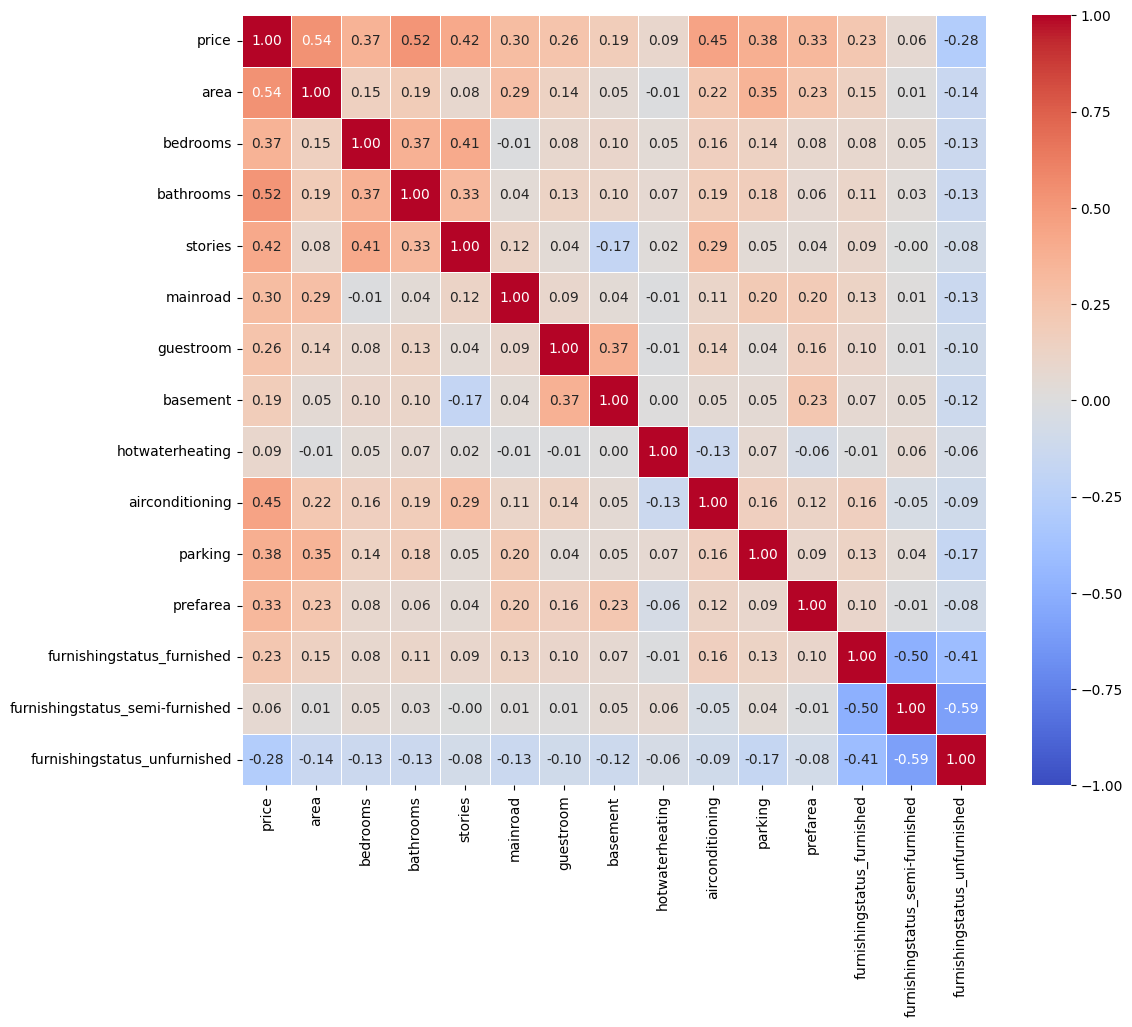

In [56]:
corr_matrix = df.corr()

plt.figure(figsize=(12, 10))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    center=0,
    linewidths=0.5)

plt.show()


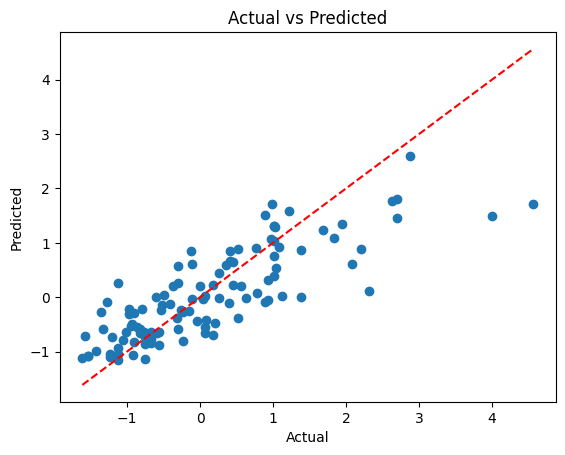

In [59]:
plt.scatter(Y_test, Y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.plot([Y_test.min(), Y_test.max()],
         [Y_test.min(), Y_test.max()],
         'r--')

plt.title("Actual vs Predicted")
plt.show()

In [60]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_furnished,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,4.566365,1.046726,4,2,3,1,0,0,0,1,1.517692,1,1,0,0
1,4.004484,1.757010,4,4,4,1,0,0,0,1,2.679409,0,1,0,0
2,4.004484,2.218232,3,2,2,1,0,1,0,0,1.517692,1,0,1,0
3,3.985755,1.083624,4,2,2,1,0,1,0,1,2.679409,1,1,0,0
4,3.554979,1.046726,4,1,2,1,1,1,0,1,1.517692,0,1,0,0


In [67]:
new_house = np.array([
    2400, 4, 3, 2,
    1, 0, 1, 0, 1,
    2, 1,
    0, 1, 0
])

pred = lin_reg.predict(new_house.reshape(1, -1))
print("Predicted price:", pred[0])

Predicted price: 659.0528272194995
